In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE   = 42
DIR_INPUT      = Path("rider_data")
RACE_FEATURES  = Path("race_data/race_features.csv")
RIDERS_SUMMARY = Path("riders_causal_inclus.csv")
TSP_PATH       = Path("team_stage_points.csv")
BEST_WINDOW    = 5  # fenêtre retenue

/Users/arthurdeletang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
#----- Clustering des étapes -----------------------------------------------------------------
rf = pd.read_csv(RACE_FEATURES, low_memory=False)
rf['date']      = pd.to_datetime(rf['date'], errors='coerce')
rf['stage_num'] = pd.to_numeric(rf['stage_num'], errors='coerce')

PHYS_FEATURES = [c for c in [
    'distance_gpx_km', 'denivele_pos', 'denivele_neg',
    'altitude_max', 'altitude_min',
    'n_cols_cat4', 'n_cols_cat3', 'n_cols_cat2', 'n_cols_cat1', 'n_cols_hc',
    'gradient_last_1km', 'gradient_last_3km', 'gradient_last_5km',
    'denivele_last_5km', 'gradient_first_50km', 'denivele_first_50km',
    'cobblestones_km', 'unpaved_km', 'compacted_gravel_km', 'paved_km', 'asphalt_km',
] if c in rf.columns]

# Une ligne par étape unique
stage_profiles = (
    rf.dropna(subset=['distance_gpx_km'])
    .drop_duplicates(subset=['course','year','stage_num'])
    .reset_index(drop=True)
)

# ── Identifier ITT/TTT à exclure du clustering ───────────────
# On les labélise manuellement en CLM=0 ; le KMeans ne doit
# pas être pollué par leurs features physiques (dist courte,
# profil plat qui les ferait confondre avec des sprints).
is_clm = (
    stage_profiles['stage'].str.lower().str.contains('prologue', na=False)
    | stage_profiles['course'].str.contains(
        r'(?:^|-)(?:clm|chrono|prologue|itt|ttt)(?:-|$)',
        case=False, regex=True, na=False,
    )
)
print(f"ITT/TTT exclus du clustering : {is_clm.sum()}")

stage_road = stage_profiles[~is_clm].copy().reset_index(drop=True)

imp    = SimpleImputer(strategy='median')
scaler = StandardScaler()
X = scaler.fit_transform(imp.fit_transform(stage_road[PHYS_FEATURES]))

# KMeans k=3 (CLM exclu — labélisé manuellement)
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
stage_road['stage_cluster_raw'] = km.fit_predict(X)

# Assigner labels stables par règle métier
profile_k3  = stage_road.groupby('stage_cluster_raw')[PHYS_FEATURES].mean()
hc_cluster  = profile_k3['n_cols_hc'].idxmax()
flat_cluster = profile_k3.drop(index=[hc_cluster])['denivele_pos'].idxmin()
mid_cluster  = profile_k3.drop(index=[hc_cluster, flat_cluster]).index[0]

label_map = {
    flat_cluster: (1, '🟢  Plat/Sprint'),
    mid_cluster : (2, '⛰️  Moy. montagne'),
    hc_cluster  : (3, '🏔️  Haute montagne'),
}
stage_road['stage_cluster']       = stage_road['stage_cluster_raw'].map({k: v[0] for k, v in label_map.items()})
stage_road['stage_cluster_label'] = stage_road['stage_cluster_raw'].map({k: v[1] for k, v in label_map.items()})

# ── Assigner CLM=0 aux ITT/TTT ───────────────────────────────
stage_clm = stage_profiles[is_clm].copy()
stage_clm['stage_cluster']       = 0
stage_clm['stage_cluster_label'] = '⏱️  CLM'

# ── Table finale (route + CLM) ───────────────────────────────
stage_profiles = pd.concat([stage_road, stage_clm], ignore_index=True)

# Lookup final — clé : (course, year, stage_num)
stage_lookup = stage_profiles[['course','year','stage_num',
                                'stage_cluster','stage_cluster_label']].copy()

print(f"✅ Étapes clusterisées : {len(stage_lookup)}")
print(stage_profiles.groupby(['stage_cluster','stage_cluster_label'])[
    ['distance_gpx_km','denivele_pos','n_cols_hc']].mean().round(1))

Étapes CLM : 394


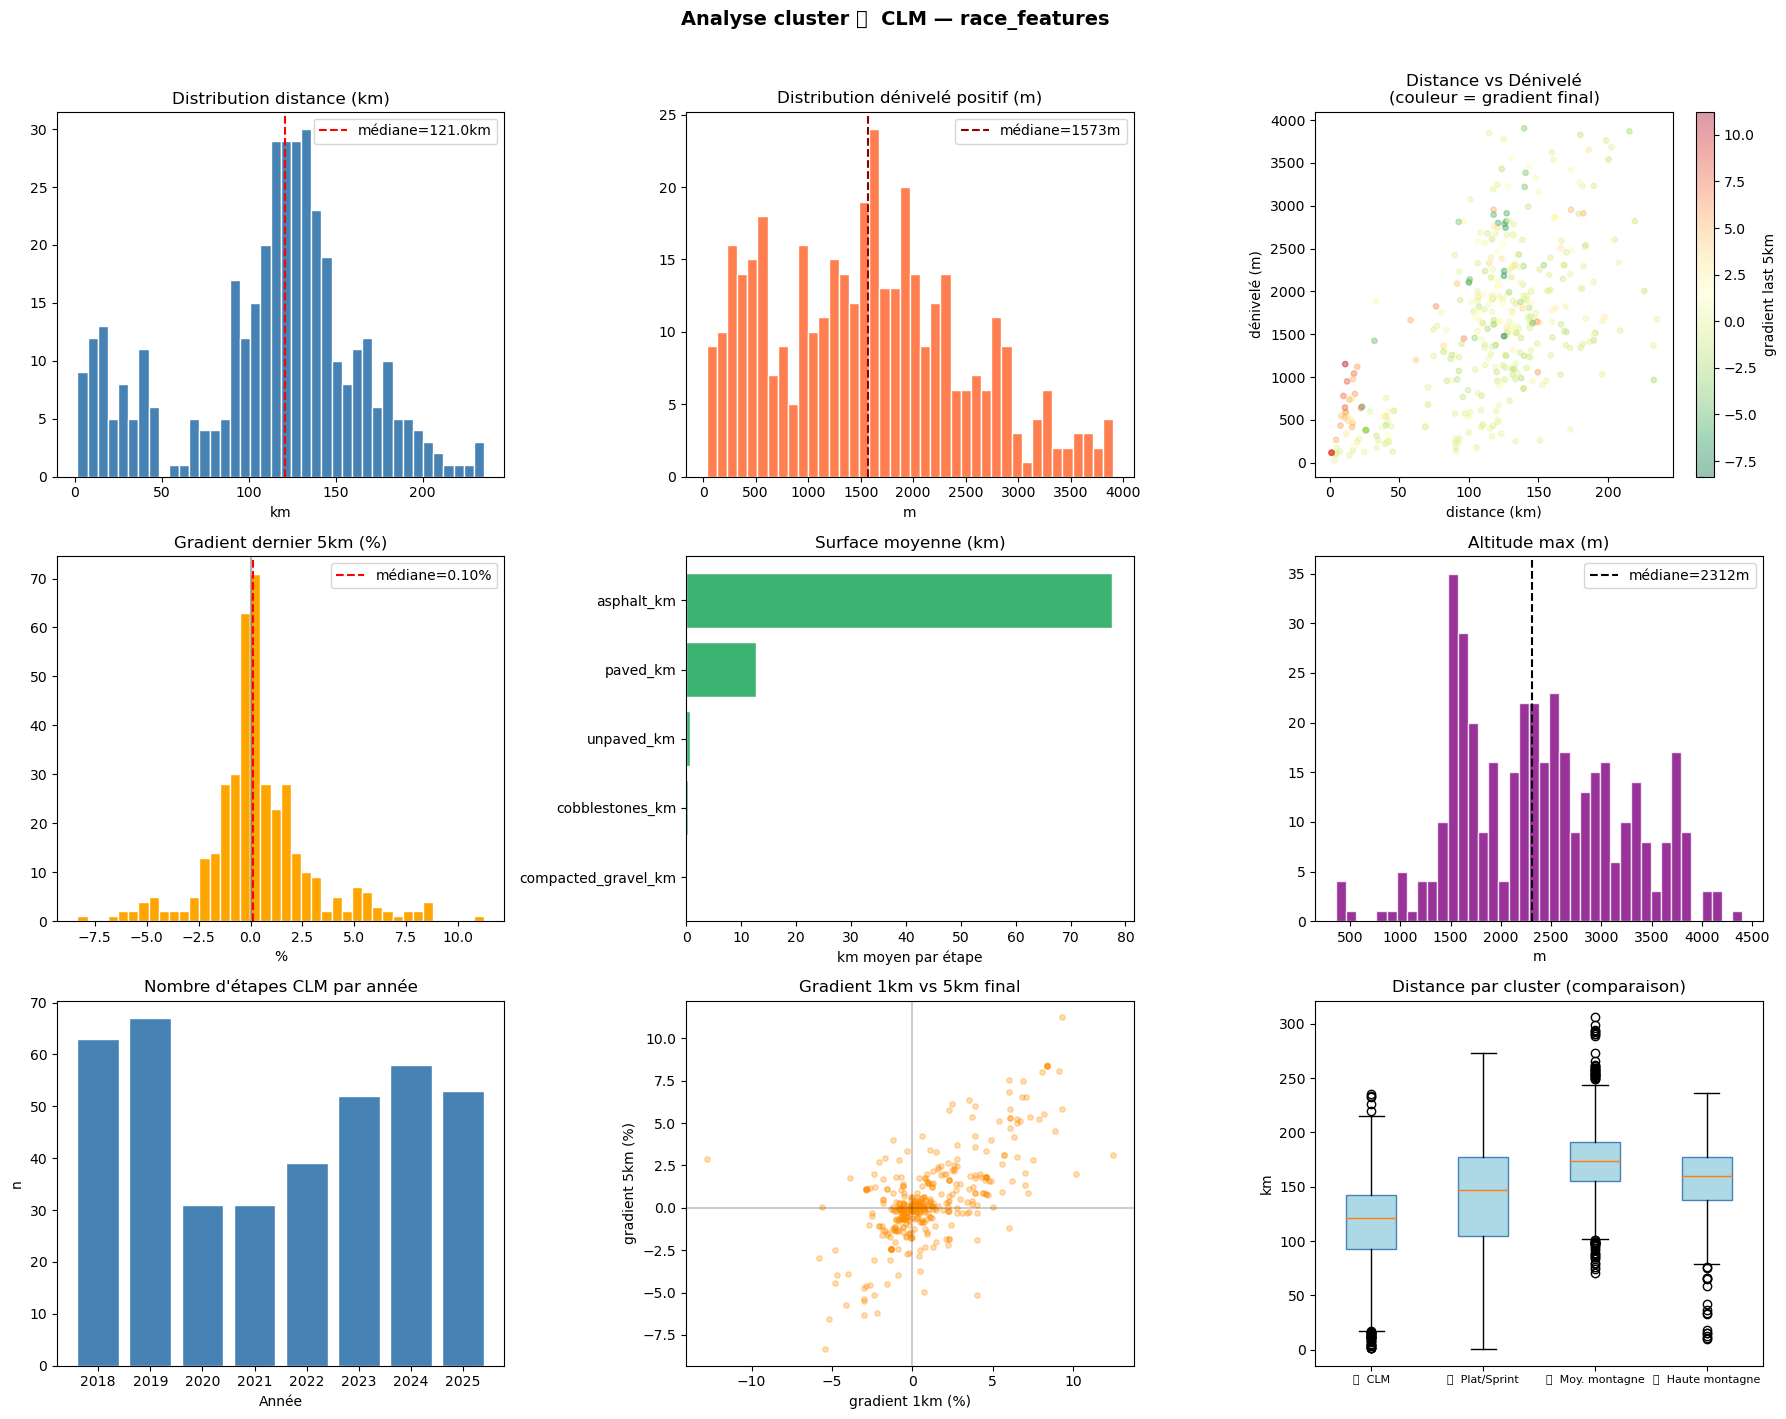


── Stats CLM ────────────────────────────────────────────
       distance_gpx_km  denivele_pos  altitude_max  gradient_last_5km  gradient_last_1km
count            394.0         394.0         394.0              394.0              394.0
mean             113.0        1573.6        2395.7                0.4                1.0
std               51.3         920.4         801.0                2.5                2.9
min                1.3          32.0         357.0               -8.3              -12.8
25%               92.6         824.8        1682.5               -0.6               -0.7
50%              121.0        1573.0        2312.5                0.1                0.4
75%              142.6        2164.8        2980.0                1.4                2.3
max              235.3        3904.0        4401.0               11.2               12.5


In [3]:
# ── Extraire les étapes CLM ──────────────────────────────────
clm = stage_profiles[stage_profiles['stage_cluster_label'] == '⏱️  CLM'].copy()
print(f"Étapes CLM : {len(clm)}")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# ── 1. Distribution distance ─────────────────────────────────
axes[0].hist(clm['distance_gpx_km'].dropna(), bins=40,
             color='steelblue', edgecolor='white')
axes[0].axvline(clm['distance_gpx_km'].median(), color='red',
                linestyle='--', label=f"médiane={clm['distance_gpx_km'].median():.1f}km")
axes[0].set_title('Distribution distance (km)')
axes[0].set_xlabel('km'); axes[0].legend()

# ── 2. Distribution dénivelé ─────────────────────────────────
axes[1].hist(clm['denivele_pos'].dropna(), bins=40,
             color='coral', edgecolor='white')
axes[1].axvline(clm['denivele_pos'].median(), color='darkred',
                linestyle='--', label=f"médiane={clm['denivele_pos'].median():.0f}m")
axes[1].set_title('Distribution dénivelé positif (m)')
axes[1].set_xlabel('m'); axes[1].legend()

# ── 3. Distance vs Dénivelé scatter ──────────────────────────
sc = axes[2].scatter(clm['distance_gpx_km'], clm['denivele_pos'],
                     alpha=0.4, s=15, c=clm['gradient_last_5km'],
                     cmap='RdYlGn_r')
plt.colorbar(sc, ax=axes[2], label='gradient last 5km')
axes[2].set_title('Distance vs Dénivelé\n(couleur = gradient final)')
axes[2].set_xlabel('distance (km)'); axes[2].set_ylabel('dénivelé (m)')

# ── 4. Distribution gradient final 5km ───────────────────────
axes[3].hist(clm['gradient_last_5km'].dropna(), bins=40,
             color='orange', edgecolor='white')
axes[3].axvline(0, color='black', linestyle='-', alpha=0.3)
axes[3].axvline(clm['gradient_last_5km'].median(), color='red',
                linestyle='--', label=f"médiane={clm['gradient_last_5km'].median():.2f}%")
axes[3].set_title('Gradient dernier 5km (%)')
axes[3].set_xlabel('%'); axes[3].legend()

# ── 5. Type de surface (km moyens) ───────────────────────────
surface_cols = [c for c in ['asphalt_km','paved_km','unpaved_km',
                             'cobblestones_km','compacted_gravel_km']
                if c in clm.columns]
surface_means = clm[surface_cols].mean().sort_values(ascending=True)
axes[4].barh(surface_means.index, surface_means.values,
             color='mediumseagreen', edgecolor='white')
axes[4].set_title('Surface moyenne (km)')
axes[4].set_xlabel('km moyen par étape')

# ── 6. Distribution altitude max ─────────────────────────────
axes[5].hist(clm['altitude_max'].dropna(), bins=40,
             color='purple', edgecolor='white', alpha=0.8)
axes[5].axvline(clm['altitude_max'].median(), color='black',
                linestyle='--', label=f"médiane={clm['altitude_max'].median():.0f}m")
axes[5].set_title('Altitude max (m)')
axes[5].set_xlabel('m'); axes[5].legend()

# ── 7. Évolution temporelle nb CLM par année ─────────────────
clm_year = (
    clm.groupby(clm['date'].dt.year)
    .size()
    .reset_index(name='n')
    .rename(columns={'date':'year'})
)
axes[6].bar(clm_year['year'], clm_year['n'],
            color='steelblue', edgecolor='white')
axes[6].set_title('Nombre d\'étapes CLM par année')
axes[6].set_xlabel('Année'); axes[6].set_ylabel('n')

# ── 8. Gradient 1km vs 5km ───────────────────────────────────
axes[7].scatter(clm['gradient_last_1km'], clm['gradient_last_5km'],
                alpha=0.3, s=15, color='darkorange')
axes[7].axhline(0, color='black', alpha=0.2)
axes[7].axvline(0, color='black', alpha=0.2)
axes[7].set_title('Gradient 1km vs 5km final')
axes[7].set_xlabel('gradient 1km (%)'); axes[7].set_ylabel('gradient 5km (%)')

# ── 9. Boxplot distance par cluster (comparaison) ────────────
bp_data = [
    stage_profiles[stage_profiles['stage_cluster'] == c]['distance_gpx_km'].dropna().values
    for c in sorted(stage_profiles['stage_cluster'].dropna().unique())
]
bp_labels = [
    stage_profiles[stage_profiles['stage_cluster'] == c]['stage_cluster_label'].iloc[0]
    for c in sorted(stage_profiles['stage_cluster'].dropna().unique())
]
axes[8].boxplot(bp_data, labels=bp_labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[8].set_title('Distance par cluster (comparaison)')
axes[8].set_ylabel('km')
axes[8].tick_params(axis='x', labelsize=8)

plt.suptitle('Analyse cluster ⏱️  CLM — race_features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Stats résumé texte ───────────────────────────────────────
print("\n── Stats CLM ────────────────────────────────────────────")
print(clm[['distance_gpx_km','denivele_pos','altitude_max',
           'gradient_last_5km','gradient_last_1km']].describe().round(1).to_string())

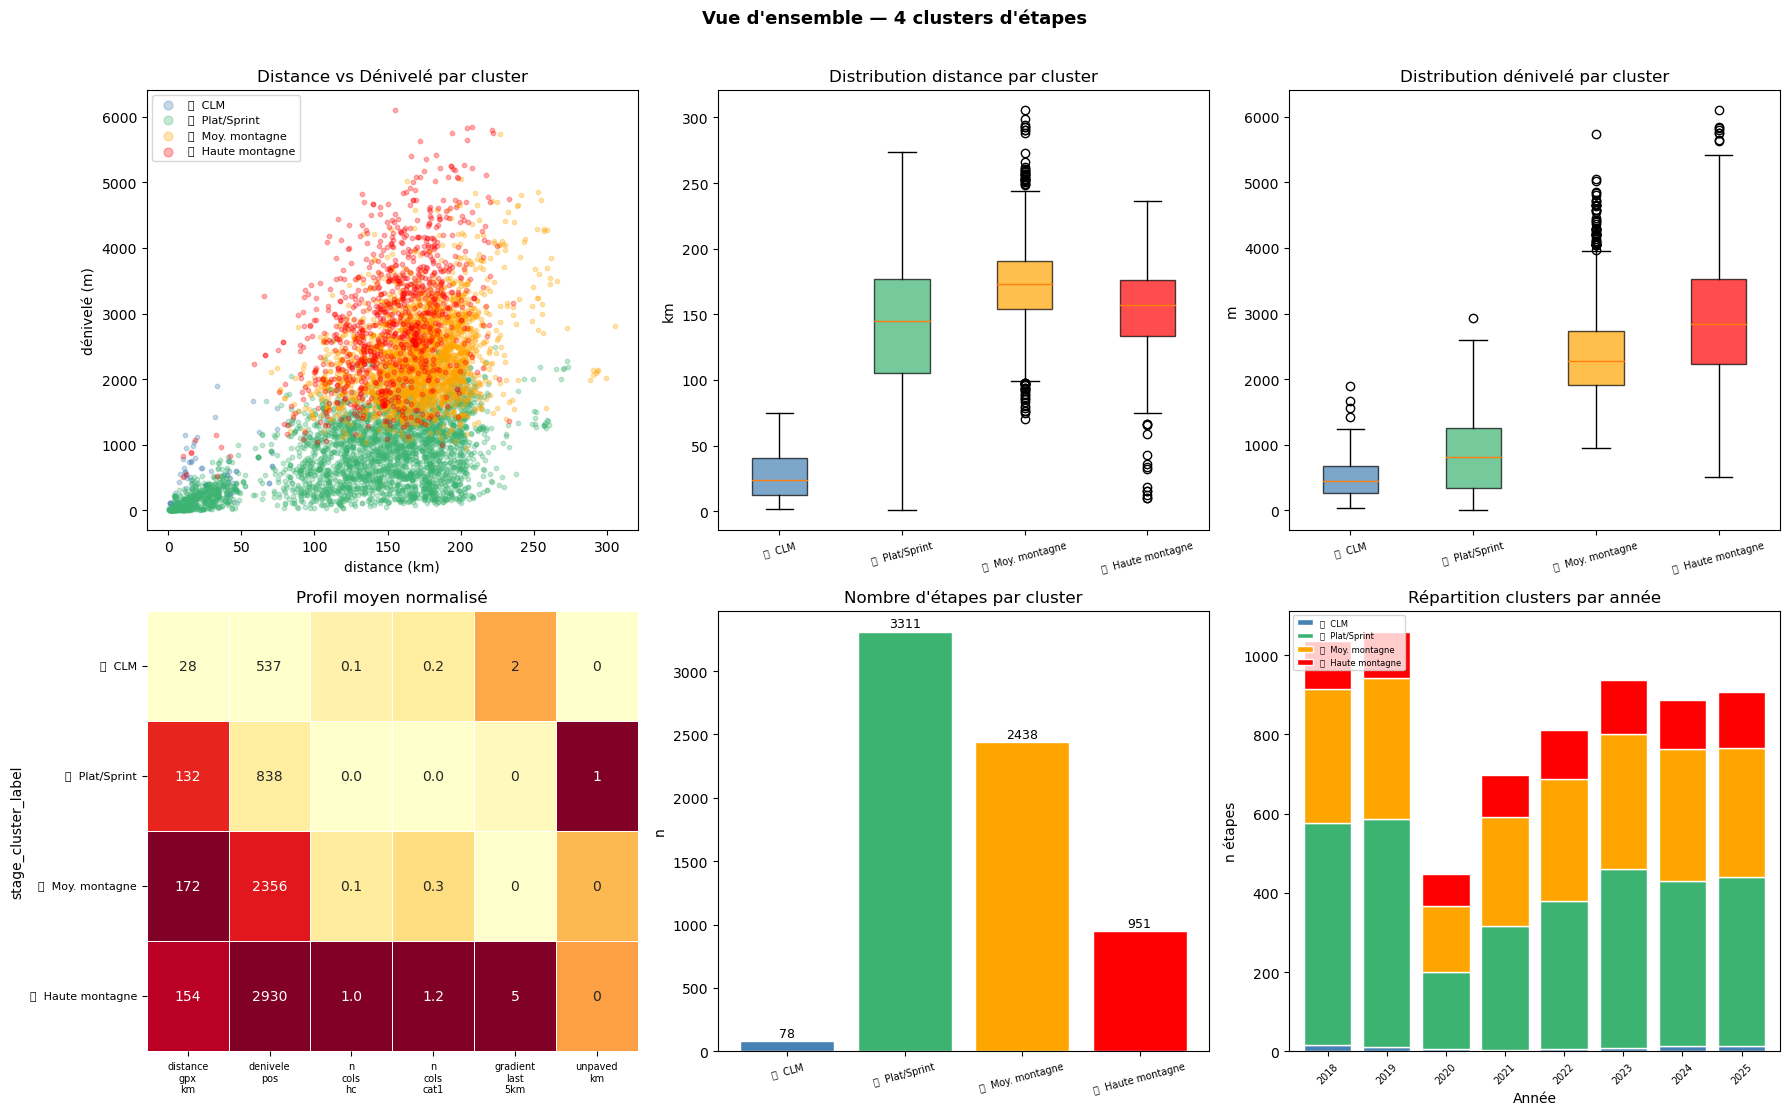

Résumé final :
                     distance_gpx_km  denivele_pos  n_cols_hc  n_cols_cat1  gradient_last_5km  unpaved_km
stage_cluster_label                                                                                      
⏱️  CLM                         27.9         537.0        0.1          0.2                2.0         0.2
🟢  Plat/Sprint                 132.1         838.3        0.0          0.0                0.1         0.8
⛰️  Moy. montagne              171.6        2355.6        0.1          0.3               -0.2         0.4
🏔️  Haute montagne             153.8        2929.8        1.0          1.2                5.3         0.5


In [5]:
LABELS_ORDER  = ['⏱️  CLM', '🟢  Plat/Sprint', '⛰️  Moy. montagne', '🏔️  Haute montagne']
COLORS_CLUSTER = {
    '⏱️  CLM'           : 'steelblue',
    '🟢  Plat/Sprint'   : 'mediumseagreen',
    '⛰️  Moy. montagne' : 'orange',
    '🏔️  Haute montagne': 'red',
}

# Garder seulement les 4 clusters
sp = stage_profiles[stage_profiles['stage_cluster_label'].isin(LABELS_ORDER)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# ── 1. Distance vs Dénivelé ──────────────────────────────────
for label in LABELS_ORDER:
    grp = sp[sp['stage_cluster_label'] == label]
    axes[0].scatter(grp['distance_gpx_km'], grp['denivele_pos'],
                    label=label, alpha=0.3, s=10,
                    color=COLORS_CLUSTER[label])
axes[0].set_title('Distance vs Dénivelé par cluster')
axes[0].set_xlabel('distance (km)'); axes[0].set_ylabel('dénivelé (m)')
axes[0].legend(fontsize=8, markerscale=2)

# ── 2. Boxplot distance ──────────────────────────────────────
data_dist = [sp[sp['stage_cluster_label'] == l]['distance_gpx_km'].dropna().values
             for l in LABELS_ORDER]
bp = axes[1].boxplot(data_dist, patch_artist=True, labels=LABELS_ORDER)
for patch, label in zip(bp['boxes'], LABELS_ORDER):
    patch.set_facecolor(COLORS_CLUSTER[label]); patch.set_alpha(0.7)
axes[1].set_title('Distribution distance par cluster')
axes[1].set_ylabel('km')
axes[1].tick_params(axis='x', labelsize=7, rotation=15)

# ── 3. Boxplot dénivelé ──────────────────────────────────────
data_deniv = [sp[sp['stage_cluster_label'] == l]['denivele_pos'].dropna().values
              for l in LABELS_ORDER]
bp2 = axes[2].boxplot(data_deniv, patch_artist=True, labels=LABELS_ORDER)
for patch, label in zip(bp2['boxes'], LABELS_ORDER):
    patch.set_facecolor(COLORS_CLUSTER[label]); patch.set_alpha(0.7)
axes[2].set_title('Distribution dénivelé par cluster')
axes[2].set_ylabel('m')
axes[2].tick_params(axis='x', labelsize=7, rotation=15)

# ── 4. Heatmap profil normalisé ──────────────────────────────
KEY_COLS_VIZ = [c for c in ['distance_gpx_km','denivele_pos','n_cols_hc',
                              'n_cols_cat1','gradient_last_5km','unpaved_km']
                if c in sp.columns]

profile_mean = sp.groupby('stage_cluster_label')[KEY_COLS_VIZ].mean().loc[LABELS_ORDER]
profile_norm = (profile_mean - profile_mean.min()) / \
               (profile_mean.max() - profile_mean.min() + 1e-9)

annots = profile_mean.copy()
for c in annots.columns:
    if any(x in c for x in ['km','denivele','distance']):
        annots[c] = annots[c].round(0).astype(int).astype(str)
    else:
        annots[c] = annots[c].round(1).astype(str)

sns.heatmap(profile_norm.loc[LABELS_ORDER],
            annot=annots.loc[LABELS_ORDER], fmt='s',
            cmap='YlOrRd', linewidths=0.5,
            xticklabels=[c.replace('_','\n') for c in KEY_COLS_VIZ],
            ax=axes[3], cbar=False)
axes[3].set_title('Profil moyen normalisé')
axes[3].tick_params(axis='x', labelsize=7)
axes[3].tick_params(axis='y', labelsize=8)

# ── 5. Répartition n étapes ──────────────────────────────────
counts = sp['stage_cluster_label'].value_counts().reindex(LABELS_ORDER)
bars = axes[4].bar(LABELS_ORDER, counts.values,
                   color=[COLORS_CLUSTER[l] for l in LABELS_ORDER],
                   edgecolor='white')
axes[4].set_title('Nombre d\'étapes par cluster')
axes[4].set_ylabel('n')
axes[4].tick_params(axis='x', labelsize=7, rotation=15)
for bar, val in zip(bars, counts.values):
    axes[4].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontsize=9)

# ── 6. Évolution par année ───────────────────────────────────
year_cluster = (
    sp.assign(year=sp['date'].dt.year)
    .groupby(['year','stage_cluster_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LABELS_ORDER, fill_value=0)
)
year_cluster.plot(
    kind='bar', stacked=True, ax=axes[5],
    color=[COLORS_CLUSTER[l] for l in LABELS_ORDER],
    edgecolor='white', width=0.8
)
axes[5].set_title('Répartition clusters par année')
axes[5].set_xlabel('Année'); axes[5].set_ylabel('n étapes')
axes[5].legend(fontsize=6, loc='upper left')
axes[5].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Vue d\'ensemble — 4 clusters d\'étapes',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Résumé texte ─────────────────────────────────────────────
print("Résumé final :")
print(sp.groupby('stage_cluster_label')[KEY_COLS_VIZ].mean().round(1)
      .reindex(LABELS_ORDER).to_string())

In [6]:
#----- Calcul forme équipe sur team_stage_points -----------------------------------------------------------------
tsp = pd.read_csv(TSP_PATH, low_memory=False)
tsp = tsp.rename(columns={'race_name': 'course'})
tsp['date']      = pd.to_datetime(tsp['date'], errors='coerce')
tsp['stage_num'] = pd.to_numeric(tsp['stage_num'], errors='coerce')
tsp['pts_uci']   = pd.to_numeric(tsp['pts_uci'], errors='coerce').fillna(0)

# Merger le cluster sur tsp
tsp = tsp.merge(
    stage_lookup, on=['course','year','stage_num'], how='left'
)

# Calcul forme — vectorisé par groupe Team × cluster
def compute_team_form(tsp, window):
    tsp = tsp.sort_values(['Team','stage_cluster','date']).copy()
    tsp['forme_equipe'] = (
        tsp.groupby(['Team','stage_cluster'])['pts_uci']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    return tsp

tsp_with_form = compute_team_form(tsp, BEST_WINDOW)

print(f"✅ Forme calculée sur {len(tsp_with_form)} lignes")
print(f"   Couverture : {tsp_with_form['forme_equipe'].notna().mean():.1%}")
print(f"   Corr(forme, pts_uci) : {tsp_with_form[['forme_equipe','pts_uci']].corr().iloc[0,1]:.4f}")

✅ Forme calculée sur 155888 lignes
   Couverture : 77.9%
   Corr(forme, pts_uci) : 0.2843


In [7]:
#----- Table Bardet (test) -----------------------------------------------------------------
FORM_COLS = ['forme_equipe', 'stage_cluster', 'stage_cluster_label']

form_lookup = tsp_with_form[[
    'course','year','stage_num','Team',
    'forme_equipe','stage_cluster','stage_cluster_label'
]].copy()

df_b = pd.read_csv(DIR_INPUT / "bardet_romain.csv", low_memory=False)
df_b['date']      = pd.to_datetime(df_b['date'], errors='coerce')
df_b['stage_num'] = pd.to_numeric(df_b['stage_num'], errors='coerce')

# Supprimer colonnes form si déjà présentes (re-run propre)
df_b = df_b.drop(columns=[c for c in FORM_COLS if c in df_b.columns])

df_b = df_b.merge(
    form_lookup,
    left_on  = ['course','year','stage_num','equipe'],
    right_on = ['course','year','stage_num','Team'],
    how='left'
).drop(columns='Team', errors='ignore')

df_b.to_csv(DIR_INPUT / "bardet_romain.csv", index=False)

print(f"✅ Bardet sauvegardé : {DIR_INPUT / 'bardet_romain.csv'}")
print(f"   Lignes    : {len(df_b)}")
print(f"   Nouvelles colonnes : {FORM_COLS}")

✅ Bardet sauvegardé : rider_data/bardet_romain.csv
   Lignes    : 2152
   Nouvelles colonnes : ['forme_equipe', 'stage_cluster', 'stage_cluster_label']


In [8]:
#----- Test Bardet -----------------------------------------------------------------
df_b = pd.read_csv(DIR_INPUT / "bardet_romain.csv", low_memory=False)
df_b['date'] = pd.to_datetime(df_b['date'], errors='coerce')

# ── Colonnes ajoutées ────────────────────────────────────────
print(f"Lignes             : {len(df_b)}")
print(f"Couverture forme   : {df_b['forme_equipe'].notna().mean():.1%}")
print(f"Couverture cluster : {df_b['stage_cluster'].notna().mean():.1%}")

# ── Par équipe × cluster ─────────────────────────────────────
print(f"\nPar équipe × cluster :")
print(
    df_b.groupby(['equipe','stage_cluster_label']).agg(
        n          = ('forme_equipe', 'size'),
        avec_forme = ('forme_equipe', lambda x: x.notna().sum()),
        couverture = ('forme_equipe', lambda x: f"{x.notna().mean():.1%}"),
        forme_moy  = ('forme_equipe', lambda x: round(x.mean(), 2))
    ).to_string()
)

# ── Anti-fuite temporelle ────────────────────────────────────
print(f"\nVérification anti-fuite (20 exemples) :")
n_ok, n_err = 0, 0
sample = df_b.dropna(subset=['forme_equipe','stage_cluster']).sample(
    min(20, df_b['forme_equipe'].notna().sum()), random_state=42)

for _, row in sample.iterrows():
    past = tsp_with_form[
        (tsp_with_form['Team']          == row['equipe']) &
        (tsp_with_form['stage_cluster'] == row['stage_cluster']) &
        (tsp_with_form['date']          <  pd.to_datetime(row['date']))
    ].tail(BEST_WINDOW)
    expected = past['pts_uci'].mean() if len(past) >= 1 else np.nan

    if pd.isna(row['forme_equipe']) and pd.isna(expected):
        n_ok += 1
    elif not pd.isna(row['forme_equipe']) and not pd.isna(expected) \
         and abs(row['forme_equipe'] - expected) < 0.01:
        n_ok += 1
    else:
        n_err += 1
        print(f"  ❌ {row['course']} ({int(row['year'])}) "
              f"forme={row['forme_equipe']:.2f} attendu={expected:.2f}")

print(f"  ✅ OK : {n_ok}  |  ❌ Erreurs : {n_err}")

# ── Spot check ───────────────────────────────────────────────
print(f"\nSpot check 10 premières lignes :")
print(
    df_b[['date','course','equipe','stage_cluster_label',
          'pts_uci_equipe_stage','forme_equipe']]
    .dropna(subset=['forme_equipe'])
    .sort_values('date')
    .head(10)
    .to_string(index=False)
)

Lignes             : 2152
Couverture forme   : 95.6%
Couverture cluster : 96.7%

Par équipe × cluster :
                                                 n  avec_forme couverture  forme_moy
equipe                    stage_cluster_label                                       
AG2R La Mondiale          ⏱️  CLM                1           0       0.0%        NaN
                          ⛰️  Moy. montagne    326         325      99.7%      29.25
                          🏔️  Haute montagne   133         132      99.2%       6.46
                          🟢  Plat/Sprint       244         243      99.6%      18.58
France                    ⛰️  Moy. montagne     29          28      96.6%      73.29
                          🏔️  Haute montagne     6           5      83.3%       0.00
                          🟢  Plat/Sprint        18          17      94.4%      76.75
Team DSM                  ⏱️  CLM                2           1      50.0%       0.00
                          ⛰️  Moy. montagne   

In [9]:
rng = np.random.default_rng(42)
sample = df_b.dropna(subset=['forme_equipe','stage_cluster']).sample(50, random_state=42)
sample['date'] = pd.to_datetime(sample['date'])

print(f"{'':2} {'date':12} {'course':28} {'equipe':25} {'cluster':20} "
      f"{'pts_eq':8} {'forme':8} {'même_eq':8} {'attendu':8} {'ok':4}")
print("-" * 130)

n_ok = 0
n_meme_equipe = 0
n_equipes_diff = 0

for _, row in sample.iterrows():
    past = tsp_with_form[
        (tsp_with_form['Team']          == row['equipe']) &
        (tsp_with_form['stage_cluster'] == row['stage_cluster']) &
        (tsp_with_form['date']          <  row['date'])
    ].tail(BEST_WINDOW)

    if len(past) == 0:
        continue

    # Vérifier si toutes les étapes passées sont dans la même équipe
    equipes_past     = past['Team'].unique()
    toutes_meme_eq   = len(equipes_past) == 1 and equipes_past[0] == row['equipe']
    n_meme_equipe   += int(toutes_meme_eq)
    n_equipes_diff  += int(not toutes_meme_eq)

    # Recalculer la moyenne attendue
    expected = past['pts_uci'].mean()
    ok = abs(row['forme_equipe'] - expected) < 0.01
    if ok: n_ok += 1

    print(f"  {'✅' if ok else '❌'} "
          f"{str(row['date'].date()):12} "
          f"{str(row['course'])[:27]:28} "
          f"{str(row['equipe'])[:24]:25} "
          f"{str(row['stage_cluster_label'])[:19]:20} "
          f"{row.get('pts_uci_equipe_stage', float('nan')):8.1f} "
          f"{row['forme_equipe']:8.2f} "
          f"{'✅ oui' if toutes_meme_eq else '⚠️ non':8} "
          f"{expected:8.2f} "
          f"{'✅' if ok else '❌':4}")

print("\n" + "=" * 60)
print(f"  Total vérifié          : {len(sample)}")
print(f"  Calcul correct (✅)    : {n_ok}")
print(f"  5 étapes même équipe   : {n_meme_equipe}")
print(f"  Équipes mixtes ⚠️      : {n_equipes_diff}")
print("=" * 60)

# ── Détail des cas équipes mixtes ────────────────────────────
if n_equipes_diff > 0:
    print(f"\nDétail cas équipes mixtes :")
    for _, row in sample.iterrows():
        past = tsp_with_form[
            (tsp_with_form['Team']          == row['equipe']) &
            (tsp_with_form['stage_cluster'] == row['stage_cluster']) &
            (tsp_with_form['date']          <  pd.to_datetime(row['date']))
        ].tail(BEST_WINDOW)
        if len(past) == 0:
            continue
        equipes_past   = past['Team'].unique()
        toutes_meme_eq = len(equipes_past) == 1 and equipes_past[0] == row['equipe']
        if not toutes_meme_eq:
            print(f"\n  Course : {row['course']} ({int(row['year'])})")
            print(f"  Équipe actuelle : {row['equipe']}")
            print(f"  Étapes passées utilisées :")
            print(past[['date','course','Team','pts_uci','stage_cluster_label']]
                  .to_string(index=False))

   date         course                       equipe                    cluster              pts_eq   forme    même_eq  attendu  ok  
----------------------------------------------------------------------------------------------------------------------------------
  ✅ 2023-03-18   milano-sanremo               Team DSM                  ⛰️  Moy. montagne        15.0     7.60 ✅ oui        7.60 ✅   
  ✅ 2020-08-07   tour-de-l-ain                AG2R La Mondiale          ⛰️  Moy. montagne         0.0     6.80 ✅ oui        6.80 ✅   
  ✅ 2023-04-08   itzulia-basque-country       Team DSM                  ⛰️  Moy. montagne         0.0     0.00 ✅ oui        0.00 ✅   
  ✅ 2022-05-04   4-jours-de-dunkerque         Team DSM                  🟢  Plat/Sprint            0.0    14.00 ✅ oui       14.00 ✅   
  ✅ 2018-02-24   faun-ardeche-classic         AG2R La Mondiale          ⛰️  Moy. montagne       220.0    13.00 ✅ oui       13.00 ✅   
  ✅ 2022-04-24   liege-bastogne-liege         Team DSM            

In [10]:
erreurs = [
    {'course': 'tour-of-croatia',  'year': 2024, 'date': '2024-10-06',
     'equipe': 'Team dsm-firmenich PostNL', 'cluster': 1},
    {'course': 'vuelta-a-espana',  'year': 2024, 'date': '2024-08-25',
     'equipe': 'Team dsm-firmenich PostNL', 'cluster': 2},
    {'course': 'gent-wevelgem',    'year': 2018, 'date': '2018-03-25',
     'equipe': 'AG2R La Mondiale',          'cluster': 1},
]

for e in erreurs:
    date = pd.to_datetime(e['date'])
    print("=" * 65)
    print(f"  {e['course']} ({e['year']})  —  {e['equipe']}")
    print("=" * 65)

    # Ce que df_b contient
    row_b = df_b[
        (df_b['course'] == e['course']) &
        (df_b['year']   == e['year']) &
        (df_b['equipe'] == e['equipe'])
    ]
    print(f"  forme_equipe dans df_b   : {row_b['forme_equipe'].values}")

    # Ce que tsp_with_form dit
    past = tsp_with_form[
        (tsp_with_form['Team']          == e['equipe']) &
        (tsp_with_form['stage_cluster'] == e['cluster']) &
        (tsp_with_form['date']          <  date)
    ].tail(BEST_WINDOW)

    print(f"  Moyenne attendue (manual): {past['pts_uci'].mean():.2f}")
    print(f"  n étapes passées         : {len(past)}")
    print(f"\n  Étapes utilisées :")
    print(past[['date','course','stage_num','Team',
                'pts_uci','stage_cluster_label']].to_string(index=False))

    # Vérifier si doublon dans tsp_with_form
    dupes = tsp_with_form[
        (tsp_with_form['Team']   == e['equipe']) &
        (tsp_with_form['course'] == e['course']) &
        (tsp_with_form['year']   == e['year'])
    ]
    print(f"\n  Lignes dans tsp_with_form pour cette course : {len(dupes)}")
    if len(dupes) > 1:
        print("  ⚠️  DOUBLONS DÉTECTÉS :")
        print

  tour-of-croatia (2024)  —  Team dsm-firmenich PostNL
  forme_equipe dans df_b   : [47.6 16.2  4.6  4.6 18.2  2.2]
  Moyenne attendue (manual): 12.60
  n étapes passées         : 5

  Étapes utilisées :
      date           course  stage_num                      Team  pts_uci stage_cluster_label
2024-10-02  tour-of-croatia        2.0 Team dsm-firmenich PostNL      0.0      🟢  Plat/Sprint
2024-10-03 munsterland-giro        NaN Team dsm-firmenich PostNL     60.0      🟢  Plat/Sprint
2024-10-04 tour-de-langkawi        6.0 Team dsm-firmenich PostNL      3.0      🟢  Plat/Sprint
2024-10-05 tour-de-langkawi        7.0 Team dsm-firmenich PostNL      0.0      🟢  Plat/Sprint
2024-10-05  tour-of-croatia        5.0 Team dsm-firmenich PostNL      0.0      🟢  Plat/Sprint

  Lignes dans tsp_with_form pour cette course : 6
  ⚠️  DOUBLONS DÉTECTÉS :
  vuelta-a-espana (2024)  —  Team dsm-firmenich PostNL
  forme_equipe dans df_b   : [10.2 48.  13.   8.  25.   8.  54.   6.   5.   7.8 10.8  5.  26.  23.8


In [11]:
#----- Généralisation -----------------------------------------------------------------
import unicodedata
from tqdm import tqdm

def normalize(s):
    return unicodedata.normalize('NFC', str(s))

# Riders à traiter : ceux présents dans riders_causal_inclus.csv
riders_set = set(normalize(r) for r in pd.read_csv(RIDERS_SUMMARY)['rider'].tolist())

# Lookup avec stage_cluster inclus
form_lookup_final = tsp_with_form[[
    'course','year','stage_num','Team',
    'forme_equipe','stage_cluster','stage_cluster_label'
]].copy()

FORM_COLS = ['forme_equipe', 'stage_cluster', 'stage_cluster_label']

all_files = [f for f in DIR_INPUT.glob("*.csv") if normalize(f.stem) in riders_set]
print(f"Fichiers à enrichir : {len(all_files)} (sur {len(list(DIR_INPUT.glob('*.csv')))} total)")

errors = []
for f in tqdm(all_files, desc="Enrichissement"):
    try:
        df = pd.read_csv(f, low_memory=False)
        df['date']      = pd.to_datetime(df['date'], errors='coerce')
        df['stage_num'] = pd.to_numeric(df['stage_num'], errors='coerce')

        # Supprimer colonnes form si déjà présentes (re-run propre)
        df = df.drop(columns=[c for c in FORM_COLS if c in df.columns])

        df = df.merge(
            form_lookup_final,
            left_on  = ['course','year','stage_num','equipe'],
            right_on = ['course','year','stage_num','Team'],
            how='left'
        ).drop(columns='Team', errors='ignore')

        df.to_csv(f, index=False)

    except Exception as e:
        errors.append((f.name, str(e)))

print(f"\n✅ {len(all_files) - len(errors)} fichiers enrichis → {DIR_INPUT}/")
if errors:
    print(f"⚠️  {len(errors)} erreurs :")
    for name, err in errors:
        print(f"   {name} : {err}")

Fichiers à enrichir : 5137 (sur 20049 total)


Enrichissement: 100%|██████████| 5137/5137 [02:57<00:00, 28.87it/s]


✅ 5124 fichiers enrichis → rider_data/
⚠️  13 erreurs :
   savitskiy_ivan.csv : You are trying to merge on float64 and object columns for key 'equipe'. If you wish to proceed you should use pd.concat
   vanderaerden_massimo.csv : You are trying to merge on float64 and object columns for key 'equipe'. If you wish to proceed you should use pd.concat
   popkov_vitaliy.csv : You are trying to merge on float64 and object columns for key 'equipe'. If you wish to proceed you should use pd.concat
   dhaene_brecht.csv : You are trying to merge on float64 and object columns for key 'equipe'. If you wish to proceed you should use pd.concat
   keizer_martijn.csv : You are trying to merge on float64 and object columns for key 'equipe'. If you wish to proceed you should use pd.concat
   cenghialta_riccardo.csv : You are trying to merge on float64 and object columns for key 'equipe'. If you wish to proceed you should use pd.concat
   ahiyevich_aleh.csv : You are trying to merge on float64 and object

In [ ]:
#----- Lookup PCS : startlist_quality, avg_temperature, won_how ----------------
import re

PCS_YEARS = range(2018, 2026)
PCS_COLS_READ = ['race_url', 'startlist_quality', 'avg_temperature', 'won_how']


def parse_race_url(url):
    """Parse PCS race URL → (course, year, stage_num).
    One-day classics → stage_num = NaN.
    Prologue → stage_num = 0.
    Stage-N → stage_num = N.
    """
    m = re.search(r'/race/([^/]+)/(\d{4})(?:/([^/?#]+))?', str(url))
    if not m:
        return None, None, np.nan
    course     = m.group(1)
    year       = int(m.group(2))
    stage_part = m.group(3)
    if stage_part is None:
        stage_num = np.nan
    elif stage_part == 'prologue':
        stage_num = 0.0
    else:
        sm = re.match(r'stage-(\d+)$', stage_part)
        stage_num = float(sm.group(1)) if sm else np.nan
    return course, year, stage_num


rows_pcs = []
for yr in PCS_YEARS:
    pcs_dir = Path(f'data/pcs{yr}')
    if not pcs_dir.exists():
        continue
    for f in pcs_dir.glob('*.csv'):
        try:
            df_tmp = pd.read_csv(f, usecols=PCS_COLS_READ, nrows=1, low_memory=False)
            row    = df_tmp.iloc[0]
            course, year, stage_num = parse_race_url(row.get('race_url', ''))
            if course is None:
                continue
            rows_pcs.append({
                'course'            : course,
                'year'              : year,
                'stage_num'         : stage_num,
                'startlist_quality' : pd.to_numeric(row.get('startlist_quality'), errors='coerce'),
                'avg_temperature'   : pd.to_numeric(row.get('avg_temperature'), errors='coerce'),
                'won_how'           : row.get('won_how'),
            })
        except Exception:
            pass

pcs_lookup = (
    pd.DataFrame(rows_pcs)
    .drop_duplicates(subset=['course', 'year', 'stage_num'])
    .reset_index(drop=True)
)
PCS_COLS_ADD = ['startlist_quality', 'avg_temperature', 'won_how']

print(f"✅ Lookup PCS : {len(pcs_lookup)} étapes ({PCS_YEARS[0]}–{PCS_YEARS[-1]})")
print(f"   startlist_quality : {pcs_lookup['startlist_quality'].notna().mean():.1%}")
print(f"   avg_temperature   : {pcs_lookup['avg_temperature'].notna().mean():.1%}")
print(f"   won_how           : {pcs_lookup['won_how'].notna().mean():.1%}")
print(pcs_lookup.head())

In [ ]:
#----- Ajout startlist_quality / avg_temperature / won_how à rider_data --------
# Clé : (course, year, stage_num). One-day classics (stage_num=NaN) gérés via sentinel -1.

riders_set_pcs = set(normalize(r) for r in pd.read_csv(RIDERS_SUMMARY)['rider'].tolist())
all_files_pcs  = [f for f in DIR_INPUT.glob("*.csv") if normalize(f.stem) in riders_set_pcs]
print(f"Fichiers à enrichir : {len(all_files_pcs)}")

# Sentinel pour les NaN stage_num (classiques 1 jour) → -1
pcs_lkp = pcs_lookup.copy()
pcs_lkp['_stage_key'] = pcs_lkp['stage_num'].fillna(-1)

errors_pcs = []
for f in tqdm(all_files_pcs, desc="PCS features"):
    try:
        df = pd.read_csv(f, low_memory=False)
        df['stage_num'] = pd.to_numeric(df['stage_num'], errors='coerce')

        # Supprimer colonnes si déjà présentes (re-run propre)
        df = df.drop(columns=[c for c in PCS_COLS_ADD if c in df.columns])

        df['_stage_key'] = df['stage_num'].fillna(-1)
        df = df.merge(
            pcs_lkp[['course', 'year', '_stage_key'] + PCS_COLS_ADD],
            on=['course', 'year', '_stage_key'],
            how='left'
        ).drop(columns=['_stage_key'])

        df.to_csv(f, index=False)
    except Exception as e:
        errors_pcs.append((f.name, str(e)))

print(f"\n✅ {len(all_files_pcs) - len(errors_pcs)} fichiers enrichis → {DIR_INPUT}/")
print(f"   Nouvelles colonnes : {PCS_COLS_ADD}")
if errors_pcs:
    print(f"⚠️  {len(errors_pcs)} erreurs :")
    for name, err in errors_pcs[:5]:
        print(f"   {name}: {err}")

# ── Vérification rapide ──────────────────────────────────────────────────────
df_check = pd.read_csv(DIR_INPUT / "vingegaard_jonas.csv", low_memory=False)
print(f"\nVérification vingegaard_jonas :")
print(df_check[['date', 'course', 'stage_num', 'startlist_quality', 'avg_temperature', 'won_how']]
      .dropna(subset=['startlist_quality'])
      .sort_values('date')
      .head(10)
      .to_string(index=False))

In [ ]:
#----- Calcul is_team_leader par cluster -----------------------------------------------
# Pour chaque (equipe, year, stage_cluster), quel coureur a cumulé le plus de pts_uci
# sur les courses sélectionnées ? Ce coureur reçoit is_team_leader=1, les autres 0.
# Les triplets où l'équipe n'a jamais scoré (pts_sum=0) ne désignent personne leader.

from tqdm import tqdm
import unicodedata

def normalize(s):
    return unicodedata.normalize('NFC', str(s))

riders_set_rl = set(normalize(r) for r in pd.read_csv(RIDERS_SUMMARY)['rider'].tolist())
all_files_rl  = [f for f in DIR_INPUT.glob("*.csv") if normalize(f.stem) in riders_set_rl]

# ── Pass 1 : agréger pts_uci par (rider, equipe, year, stage_cluster) ──────
print("Pass 1/2 — Agrégation pts_uci...")
agg_rows = []
for f in tqdm(all_files_rl, desc="Lecture"):
    try:
        df = pd.read_csv(f, low_memory=False)
        df['pts_uci']       = pd.to_numeric(df['pts_uci'],       errors='coerce').fillna(0)
        df['stage_cluster'] = pd.to_numeric(df['stage_cluster'], errors='coerce')
        df_sel = df[
            (df['selected'] == 1) &
            df['stage_cluster'].notna() &
            df['equipe'].notna()
        ]
        if len(df_sel) == 0:
            continue
        agg = (
            df_sel.groupby(['equipe', 'year', 'stage_cluster'])['pts_uci']
            .sum()
            .reset_index()
            .rename(columns={'pts_uci': 'pts_sum'})
        )
        agg['rider'] = f.stem
        agg_rows.append(agg)
    except Exception:
        pass

df_agg = pd.concat(agg_rows, ignore_index=True)

# ── Identifier le leader : argmax pts_sum par (equipe, year, cluster) ───────
# On exclut les triplets où tout le monde est à 0 (pas de leader à désigner)
df_agg_pos = df_agg[df_agg['pts_sum'] > 0].copy()
idx_max    = df_agg_pos.groupby(['equipe', 'year', 'stage_cluster'])['pts_sum'].idxmax()
df_leaders = (
    df_agg_pos.loc[idx_max, ['equipe', 'year', 'stage_cluster', 'rider']]
    .copy()
    .rename(columns={'rider': 'leader'})
)
print(f"  {len(df_leaders)} triplets (equipe, year, cluster) avec un leader désigné")

# ── Pass 2 : écrire is_team_leader dans chaque rider CSV ────────────────────
print("\nPass 2/2 — Écriture is_team_leader...")
errors_rl = []
for f in tqdm(all_files_rl, desc="Écriture"):
    try:
        df = pd.read_csv(f, low_memory=False)
        df['stage_cluster'] = pd.to_numeric(df['stage_cluster'], errors='coerce')
        df = df.drop(columns=['is_team_leader'], errors='ignore')

        rider_leaders = df_leaders[df_leaders['leader'] == f.stem][
            ['equipe', 'year', 'stage_cluster']
        ].copy()
        rider_leaders['is_team_leader'] = 1

        df = df.merge(rider_leaders, on=['equipe', 'year', 'stage_cluster'], how='left')
        df['is_team_leader'] = df['is_team_leader'].fillna(0).astype(int)
        df.to_csv(f, index=False)
    except Exception as e:
        errors_rl.append((f.name, str(e)))

ok = len(all_files_rl) - len(errors_rl)
print(f"\n✅ is_team_leader ajouté → {ok} fichiers")
if errors_rl:
    for n, e in errors_rl[:5]:
        print(f"   ⚠️  {n}: {e}")

# ── Vérification Van Aert ────────────────────────────────────────────────────
df_v = pd.read_csv(DIR_INPUT / "van_aert_wout.csv", low_memory=False)
print("\nVan Aert — taux is_team_leader par (year, stage_cluster_label) :")
print(
    df_v[df_v['selected'] == 1]
    .groupby(['year', 'stage_cluster_label'])['is_team_leader']
    .mean()
    .round(2)
    .unstack()
    .to_string()
)